In [1]:

import cv2
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import PIL.Image

In [2]:
input_video_path = "single_channel.mp4"
output_csv_path = "single_results.csv"


In [3]:
# 1. Initialize Video Capture
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video {input_video_path}")
    exit()

# List to store data for each frame
data_log = []

frame_count = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 240
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
display_every_n_frames = 100

cx = 349
cy = 543

window_size_h = 220
window_size_w = 300

# Centered square crop window with bounds clamped to the frame
half_window_h = window_size_h // 2
half_window_w = window_size_w // 2
x1 = cx - half_window_w
y1 = cy - half_window_h
x2 = cx + half_window_w
y2 = cy + half_window_h

# ROI (bottom-right of cropped frame)
roi_size = 50
prev_brightness = None
change_threshold = 5
brightness_frames = []

roi_cx = 678
roi_cy = 659


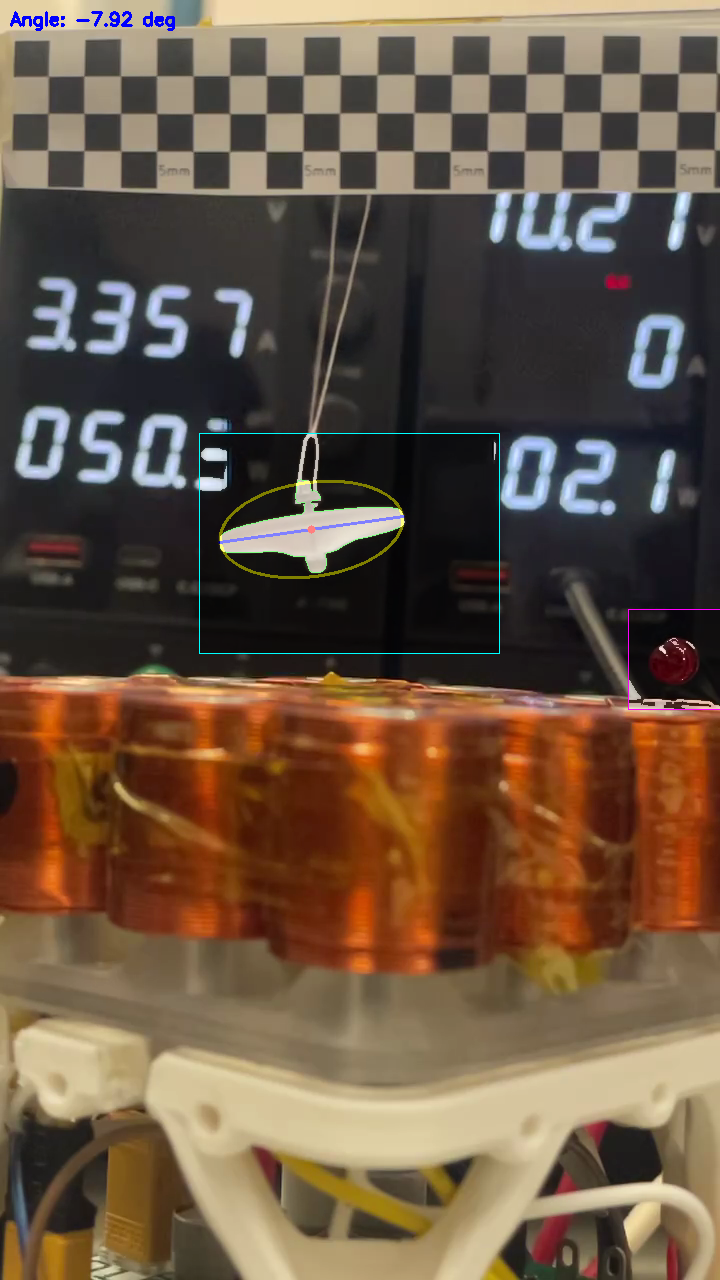


Success! Data saved to: single_results.csv


In [4]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    mx1 = max(x1, 0)
    my1 = max(y1, 0)
    mx2 = min(x2, frame_width)
    my2 = min(y2, frame_height)
    cropped = frame[my1:my2, mx1:mx2]

    if cropped.size == 0:
        continue

    # 1) Build two grayscale crops: main analysis crop and ROI crop.
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

    rrx1 = max(roi_cx - roi_size, 0)
    rry1 = max(roi_cy - roi_size, 0)
    rrx2 = min(roi_cx + roi_size, frame_width)
    rry2 = min(roi_cy + roi_size, frame_height)
    roi_crop = frame[rry1:rry2, rrx1:rrx2]

    if roi_crop.size > 0:
        gray_roi = cv2.cvtColor(roi_crop, cv2.COLOR_BGR2GRAY)
        _, binary_roi = cv2.threshold(gray_roi, 100, 255, cv2.THRESH_BINARY)
        current_brightness = cv2.mean(binary_roi)[0]
    else:
        gray_roi = np.zeros((1, 1), dtype=np.uint8)
        binary_roi = gray_roi
        current_brightness = 0.0

    # 2) Brightness-change detection uses only the ROI crop.
    if prev_brightness is not None and abs(prev_brightness - current_brightness) > change_threshold:
        print(f"Brightness drop detected at frame {frame_count}: {current_brightness:.2f}")
        brightness_frames.append(frame_count)
    prev_brightness = current_brightness

    # 3) Disconnect thin strings/sticks using Morphological Opening.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 4) Find contours and strictly keep only the largest one.
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    frame_data = {
        "frame": frame_count, "timestamp_sec": frame_count / fps, "detected": False,
        "line_point_x": None, "line_point_y": None, "line_dir_x": None, "line_dir_y": None,
        "line_angle_deg": None, "longest_width_px": None
    }

    # Draw on original frame so overlays are spatially meaningful.
    overlay = frame.copy()

    if contours:
        best_cnt = max(contours, key=cv2.contourArea)

        # Only process if the blob is substantial.
        if cv2.contourArea(best_cnt) > 200:
            isolated_disk = np.zeros_like(gray)
            cv2.drawContours(isolated_disk, [best_cnt], -1, 255, cv2.FILLED)

            y_idx, x_idx = np.nonzero(isolated_disk)
            pts = np.column_stack((x_idx, y_idx)).astype(np.float32)

            if len(pts) >= 10:
                mean, eigenvectors, eigenvalues = cv2.PCACompute2(pts, mean=None)
                cx_local, cy_local = mean[0, 0], mean[0, 1]

                vx, vy = eigenvectors[0, 0], eigenvectors[0, 1]
                angle_rad = math.atan2(vy, vx)
                angle_deg = math.degrees(angle_rad)

                centered = pts - mean[0]
                proj_major = np.dot(centered, eigenvectors[0])
                proj_minor = np.dot(centered, eigenvectors[1])

                major_len = float(proj_major.max() - proj_major.min())
                minor_len = float(proj_minor.max() - proj_minor.min())

                if angle_deg > 90:
                    angle_deg -= 180
                elif angle_deg < -90:
                    angle_deg += 180

                # Convert local crop coordinates to full-frame coordinates.
                cx_full = float(cx_local + mx1)
                cy_full = float(cy_local + my1)

                frame_data.update({
                    "detected": True, "line_point_x": round(cx_full, 2), "line_point_y": round(cy_full, 2),
                    "line_dir_x": round(float(vx), 4), "line_dir_y": round(float(vy), 4),
                    "line_angle_deg": round(angle_deg, 2), "longest_width_px": round(major_len, 2)
                })

                best_cnt_full = best_cnt.copy()
                best_cnt_full[:, :, 0] += mx1
                best_cnt_full[:, :, 1] += my1
                cv2.drawContours(overlay, [best_cnt_full], -1, (0, 255, 0), 1)

                rx, ry = int(major_len / 2), int(minor_len / 2)
                cv2.ellipse(overlay, (int(cx_full), int(cy_full)), (rx, ry), angle_deg, 0, 360, (0, 255, 255), 2)

                L = major_len / 2
                pt1 = (int(cx_full - vx * L), int(cy_full - vy * L))
                pt2 = (int(cx_full + vx * L), int(cy_full + vy * L))
                cv2.line(overlay, pt1, pt2, (255, 0, 0), 2)
                cv2.circle(overlay, (int(cx_full), int(cy_full)), 4, (0, 0, 255), -1)

                cv2.putText(overlay, f"Angle: {angle_deg:.2f} deg", (10, 25),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # 5) Overlay both grayscale crops on top of original frame.
    main_mask_bgr = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    if (my2 > my1) and (mx2 > mx1) and overlay[my1:my2, mx1:mx2].shape[:2] == main_mask_bgr.shape[:2]:
        overlay[my1:my2, mx1:mx2] = cv2.addWeighted(overlay[my1:my2, mx1:mx2], 0.5, main_mask_bgr, 0.5, 0)

    roi_mask_bgr = cv2.cvtColor(binary_roi, cv2.COLOR_GRAY2BGR)
    if (rry2 > rry1) and (rrx2 > rrx1) and overlay[rry1:rry2, rrx1:rrx2].shape[:2] == roi_mask_bgr.shape[:2]:
        overlay[rry1:rry2, rrx1:rrx2] = cv2.addWeighted(overlay[rry1:rry2, rrx1:rrx2], 0.5, roi_mask_bgr, 0.5, 0)

    cv2.rectangle(overlay, (mx1, my1), (mx2, my2), (255, 255, 0), 1)
    cv2.rectangle(overlay, (rrx1, rry1), (rrx2, rry2), (255, 0, 255), 1)

    data_log.append(frame_data)

    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames...")

    if frame_count % display_every_n_frames == 0:
        img = PIL.Image.fromarray(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

# Clean up and save results
cap.release()
df = pd.DataFrame(data_log)
df.to_csv(output_csv_path, index=False)
print(f"\nSuccess! Data saved to: {output_csv_path}")


Segment 0: Frames 353 to 573, Mean Angle: 3.11
Segment 1: Frames 613 to 753, Mean Angle: 3.91
Segment 2: Frames 793 to 932, Mean Angle: 3.15
Segment 3: Frames 972 to 1111, Mean Angle: 2.55
Segment 4: Frames 1151 to 1289, Mean Angle: 2.17
Segment 5: Frames 1329 to 1468, Mean Angle: 0.95
Segment 6: Frames 1508 to 1647, Mean Angle: -0.24
Segment 7: Frames 1687 to 1827, Mean Angle: -1.13
Segment 8: Frames 1867 to 2007, Mean Angle: -2.37
Segment 9: Frames 2047 to 2186, Mean Angle: -4.85


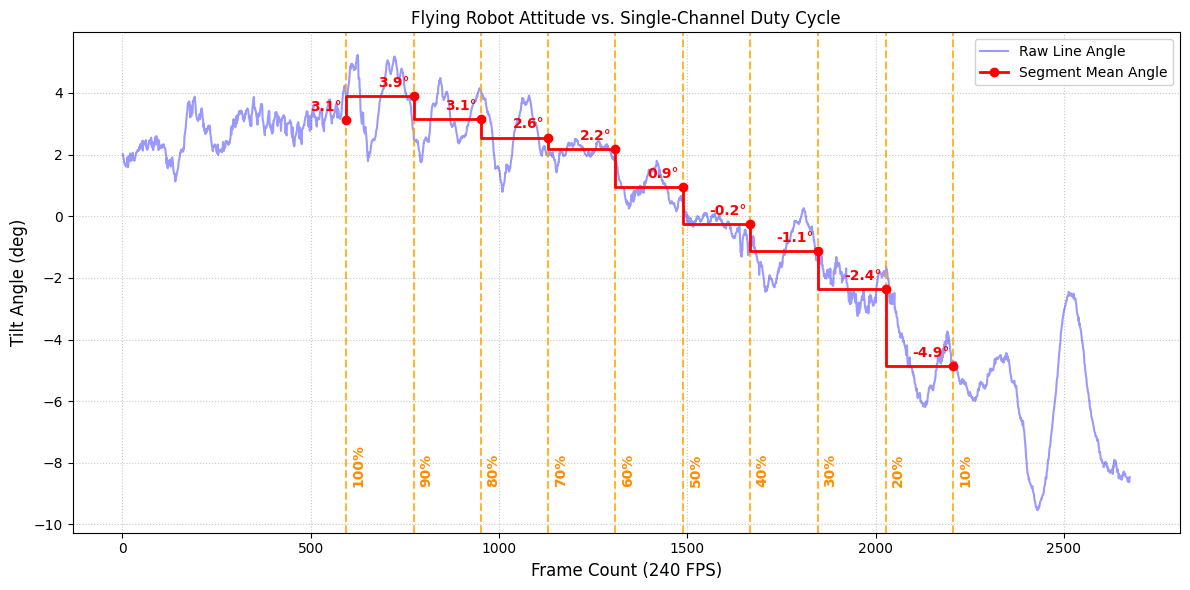

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and filter detections
df = pd.read_csv(output_csv_path)
df = df[df['detected']].copy()

# Compute segment means robustly based on actual frame values
mean_segment_angles = []
segment_buffer = 20

for i, time in enumerate(brightness_frames):
    seg_start = brightness_frames[i-1] + segment_buffer if i > 0 else brightness_frames[0] - 240
    seg_end = time - segment_buffer
    
    # Robust frame-based filtering (avoids Pandas index mismatch issues)
    seg = df[(df['frame'] >= seg_start) & (df['frame'] <= seg_end)]['line_angle_deg']
    mean_val = seg.mean()
    mean_segment_angles.append(mean_val)
    print(f"Segment {i}: Frames {seg_start} to {seg_end}, Mean Angle: {mean_val:.2f}")

# Plotting Configuration
plt.figure(figsize=(12, 6))

# Plot raw angles with slight transparency so annotations pop out
plt.plot(df['frame'], df['line_angle_deg'], 'b-', alpha=0.4, label='Raw Line Angle')

# Calculate dynamic y-offsets for text placement
y_min, y_max = df['line_angle_deg'].min(), df['line_angle_deg'].max()
y_range = y_max - y_min

# Plot Vertical Lines & Percentages
for i, bt in enumerate(brightness_frames):
    # Plot line without a label to remove it from the legend
    plt.axvline(bt, color='orange', linestyle='--', alpha=0.8)
    
    # Label the percentage vertically next to the line
    percentage_str = f'{100 - i*10}%'
    plt.text(bt + 15, y_min + y_range * 0.05, percentage_str, 
             color='darkorange', rotation=90, va='bottom', ha='left', 
             fontweight='bold', fontsize=10)

# Plot Step Function for Averages
plt.plot(brightness_frames, mean_segment_angles, 'ro-', drawstyle='steps-pre', 
         linewidth=2, markersize=6, label='Segment Mean Angle')

# Annotate each step with the exact average value
for i, (bt, mean_angle) in enumerate(zip(brightness_frames, mean_segment_angles)):
    if pd.notna(mean_angle):
        # Position the text slightly above the red marker
        plt.text(bt - 10, mean_angle + (y_range * 0.02), f"{mean_angle:.1f}°", 
                 color='red', fontweight='bold', fontsize=10, ha='right')

# Formatting and Labels
plt.title('Flying Robot Attitude vs. Single-Channel Duty Cycle')
plt.xlabel('Frame Count (240 FPS)', fontsize=12)
plt.ylabel('Tilt Angle (deg)', fontsize=12)

# Legend and Grid
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()